#### **2. Logistic Regression: Preprocessing, Interpretation, and Evaluation**

In [19]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

# Four numeric features: 3 informative, 1 redundant (a linear combination of them)
X_num, y = make_classification(
    n_samples=600,
    n_features=4,
    n_informative=3,
    n_redundant=1,
    class_sep=0.9,         # how far apart the two class clusters sit
    weights=[0.68, 0.32],  # class imbalance: 68% negative, 32% positive
    flip_y=0.03,           # 3% of labels randomly flipped (label noise)
    random_state=21
)

df = pd.DataFrame(X_num, columns=["x1", "x2", "x3", "x4"])
rng = np.random.default_rng(21)
df["region"] = rng.choice(["north", "south", "east"], size=len(df))  # nominal, 3 levels
df["device"] = rng.choice(["mobile", "desktop"], size=len(df))       # nominal, 2 levels
df.loc[rng.choice(len(df), 25, replace=False), "x3"] = np.nan        # 25 missing values

In [20]:
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# Figure output quality settings
plt.rcParams['figure.dpi']     = 120    # on-screen preview
plt.rcParams['savefig.dpi']    = 500    # saved PNG files
plt.rcParams['savefig.bbox']   = 'tight'
plt.rcParams['font.size']      = 11
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.25
plt.rcParams['grid.linewidth'] = 0.6


def save_fig(name):
    """Save the current figure to figures/<name>.png at 500 dpi."""
    plt.savefig(f'figures/{name}.png', bbox_inches='tight')

---
**Question 1**

Explain why passing string-valued columns directly to `LogisticRegression` throws a runtime error. Furthermore, explain why applying basic `LabelEncoder` mapping categories to integers $\{0, 1, 2\}$ introduces a spurious ordinal assumption that degrades model generalizability.

---


Logistic Regression cannot directly use string values such as `"north"`, `"south"`, `"east"`, `"mobile"`, or `"desktop"`. The model works with numerical values. It first calculates a linear score

$$
z = \mathbf{w}^T\mathbf{x} + b
$$

and then applies the sigmoid function

$$
p = \frac{1}{1+e^{-z}}
$$

Because of this, the input features need to be numerical. If string columns are given directly to `LogisticRegression`, scikit-learn tries to convert the values into numbers. Values such as `"north"` cannot be converted, so an error like the following can occur:

```python
ValueError: could not convert string to float: 'north'
```

Using `LabelEncoder` is also not a good solution for nominal categorical features. For example, suppose the `region` values are encoded as

```text
east  -> 0
north -> 1
south -> 2
```

Logistic Regression would then treat these values as numerical quantities. This creates an artificial ordering:

$$
\text{south} > \text{north} > \text{east}.
$$

It also assumes that the distance between `east` and `north` is the same as the distance between `north` and `south`.

There is no such relationship between these regions. They are nominal categories, so there is no natural order or numerical distance between them. This is known as a spurious ordinal assumption.

Because of this, the model could learn patterns based on the arbitrary numbers assigned by `LabelEncoder`. Also, changing the encoding, for example by assigning `east -> 2` instead of `east -> 0`, could change the model even though the original data has not changed.

---
**Question 2**

Construct a scikit-learn `Pipeline` combined with `ColumnTransformer` that:

- Imputes missing numerical entries with training set column medians;
- Standardizes numerical features ($\mu = 0, \sigma = 1$);
- Imputes missing categorical features using the most frequent mode;
- One-hot encodes categorical attributes; and
- Fits a Logistic Regression classifier.

Split the dataset into training (80%) and test (20%) subsets using a stratified split with `random_state=42`.

---


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ["x1", "x2", "x3", "x4"]     # numerical features
cat_cols = ["region", "device"]         # categorical features

X = df[num_cols + cat_cols]

# Stratified 80:20 split, so both sets keep the same class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

# Numerical: fill missing with the median, then standardize
num_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# Categorical: fill missing with the mode, then one-hot encode
cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Apply each sub-pipeline to its own set of columns
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

# Full pipeline: preprocessing + classifier
clf = Pipeline([
    ("pre", preprocessor),
    ("model", LogisticRegression(max_iter=1000)),
])

clf.fit(X_train, y_train)

print(f"Train size: {X_train.shape[0]}, test size: {X_test.shape[0]}")
print(f"Positive class share - train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")
print(f"Missing x3 values    - train: {X_train['x3'].isna().sum()}, "
      f"test: {X_test['x3'].isna().sum()}")

# Column names after one-hot encoding
print("\nFeatures after preprocessing:")
print(list(clf.named_steps["pre"].get_feature_names_out()))

print(f"\nTrain accuracy: {clf.score(X_train, y_train):.4f}")
print(f"Test accuracy : {clf.score(X_test, y_test):.4f}")

Train size: 480, test size: 120
Positive class share - train: 0.329, test: 0.325
Missing x3 values    - train: 22, test: 3

Features after preprocessing:
['num__x1', 'num__x2', 'num__x3', 'num__x4', 'cat__region_east', 'cat__region_north', 'cat__region_south', 'cat__device_desktop', 'cat__device_mobile']

Train accuracy: 0.8854
Test accuracy : 0.8500


---
**Question 3**

Perform a grid search over regularization strengths $C \in \{0.01, 0.1, 1, 10, 100\}$ and penalty types penalty $\in \{\ell_1, \ell_2\}$ using `solver='liblinear'` and 5-fold Stratified Cross-Validation. Optimize for $F_1$-score. Report best parameters and cross-validation score.

---


In [22]:
import warnings

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# sklearn 1.8+ deprecates penalty= in favour of l1_ratio, but Q3 asks for
# penalty in {l1, l2}, so keep penalty= and hide the deprecation notices
warnings.filterwarnings("ignore", message="'penalty' was deprecated")
warnings.filterwarnings("ignore", message="Inconsistent values: penalty")

# Same pipeline as Q2, but with liblinear so both l1 and l2 are supported
grid_clf = Pipeline([
    ("pre", preprocessor),
    ("model", LogisticRegression(solver="liblinear", max_iter=1000)),
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
}

# 5-fold stratified CV keeps the class balance in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = GridSearchCV(grid_clf, param_grid, cv=cv, scoring="f1")
search.fit(X_train, y_train)

best_model = search.best_estimator_    # refit on the full training set

print(f"Best parameters : C = {search.best_params_['model__C']}, "
      f"penalty = {search.best_params_['model__penalty']}")
print(f"Best CV F1-score: {search.best_score_:.4f}")

# Mean CV F1 for every combination in the grid
print(f"\n{'C':>8}{'l1':>10}{'l2':>10}")
results = search.cv_results_
for C in param_grid["model__C"]:
    scores = []
    for penalty in ("l1", "l2"):
        i = next(k for k, p in enumerate(results["params"])
                 if p["model__C"] == C and p["model__penalty"] == penalty)
        scores.append(results["mean_test_score"][i])
    print(f"{C:>8}{scores[0]:>10.4f}{scores[1]:>10.4f}")

Best parameters : C = 1, penalty = l1
Best CV F1-score: 0.8148

       C        l1        l2
    0.01    0.7418    0.7843
     0.1    0.8007    0.8033
       1    0.8148    0.8073
      10    0.7997    0.7997
     100    0.7997    0.7997


---
**Question 4**

On the test set, evaluate and report accuracy, precision, recall, $F_1$-score, and confusion matrix. Explain why overall accuracy can be deeply misleading when dealing with class-imbalanced datasets (e.g., 68% negative, 32% positive).

---


In [23]:
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             confusion_matrix, f1_score, precision_score,
                             recall_score)

# Predict with the best model found by the Q3 grid search
y_pred = best_model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion matrix:\n{cm}")

tn, fp, fn, tp = cm.ravel()
print(f"\nTN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")

# Accuracy of a baseline that always predicts the majority (negative) class
baseline = 1 - y_test.mean()
print(f"\nMajority-class baseline accuracy: {baseline:.4f}")

Accuracy : 0.8583
Precision: 0.7895
Recall   : 0.7692
F1-score : 0.7792

Confusion matrix:
[[73  8]
 [ 9 30]]

TN = 73, FP = 8, FN = 9, TP = 30

Majority-class baseline accuracy: 0.6750


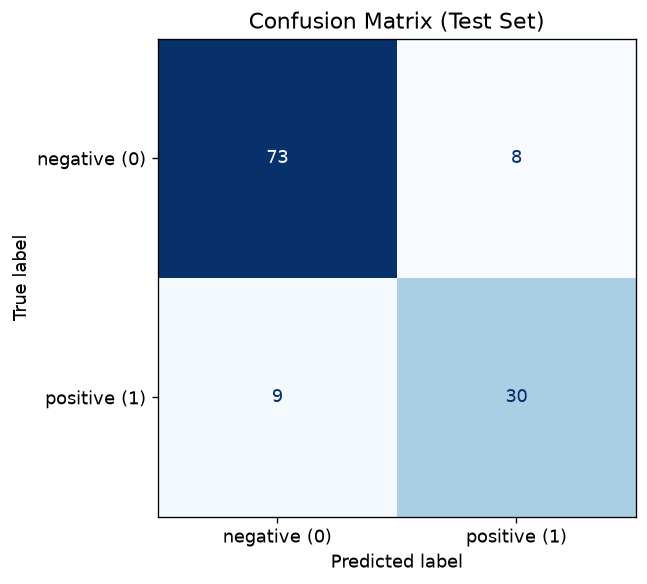

In [24]:
fig, ax = plt.subplots(figsize=(5.5, 5))

ConfusionMatrixDisplay(cm, display_labels=["negative (0)", "positive (1)"]).plot(
    ax=ax, cmap="Blues", colorbar=False)

ax.grid(False)      # the global grid setting would draw over the cells
ax.set_title("Confusion Matrix (Test Set)")

plt.tight_layout()
save_fig("q2_4_confusion_matrix")
plt.show()

**Test-set results:**

| Metric | Value |
|---|---|
| Accuracy | 0.8583 |
| Precision | 0.7895 |
| Recall | 0.7692 |
| F1-score | 0.7792 |

Confusion matrix (rows = true, columns = predicted):

| | pred 0 | pred 1 |
|---|---|---|
| **true 0** | TN = 73 | FP = 8 |
| **true 1** | FN = 9 | TP = 30 |

Majority-class (always-0) baseline accuracy: **0.6750**.

Why overall accuracy is misleading under class imbalance

In this dataset, the classes are not balanced: about 68% of the samples belong to the negative class and 32% belong to the positive class. Because of this, accuracy alone does not give a good idea of how well the classifier is performing.

First, consider a very simple classifier that always predicts the majority class. There are 81 negative samples out of 120, so this classifier would get

$$
\frac{81}{120}=0.675
$$

Therefore, an accuracy of around 0.70 or even 0.80 does not necessarily mean that the model is learning useful patterns.

Another problem is that the majority class has a large effect on the accuracy. Accuracy is calculated as

$$
\text{Accuracy}=\frac{TP+TN}{N}
$$

Since the negative class makes up most of the test set, getting the negative predictions correct can make the accuracy look good. For example, a model that completely fails to detect the positive class and has a recall of 0 could still get 67.5% accuracy by predicting every sample as negative.

Accuracy also treats false positives and false negatives in the same way. However, these two types of errors may not have the same importance. For example, in medical diagnosis, missing a positive case can be much more serious than incorrectly identifying a negative case as positive. Accuracy does not show this difference.

For our model, the accuracy is 0.8583, which is much better than the 0.675 majority-class baseline. The model correctly identifies 30 out of the 39 positive samples. However, imagine that it detected only about 21 positive samples instead, with around 18 false negatives. The accuracy would still be about

$$
\frac{21+(81-8)}{120}
\approx 0.78,
$$

while the positive-class recall would drop to

$$
\frac{21}{21+18}
\approx 0.54.
$$

So the accuracy would still look reasonably good even though the model would be missing almost half of the positive cases.

Therefore, accuracy should not be used alone for this imbalanced dataset. Measures such as precision, recall, F1-score, the confusion matrix, and ROC/PR curves give a better picture of the model's performance. This is also why the hyperparameter search in Q2.3 used F1-score instead of accuracy.


---
**Question 5**

Adjust the classification decision boundary threshold from $p_{\text{threshold}} = 0.50$ down to $0.35$. Recompute precision and recall. Describe the Precision-Recall trade-off and outline a realistic domain application (e.g., medical diagnostics, fraud detection) where lowering the threshold is preferred.

---


In [25]:
# Predicted probability of the positive class
y_proba = best_model.predict_proba(X_test)[:, 1]

# Default predict() is the same as thresholding at 0.50
assert np.array_equal((y_proba >= 0.50).astype(int), best_model.predict(X_test))


def metrics_at(t):
    """Precision, recall, F1 and confusion matrix at threshold t."""
    pred = (y_proba >= t).astype(int)
    return (precision_score(y_test, pred), recall_score(y_test, pred),
            f1_score(y_test, pred), confusion_matrix(y_test, pred))


print(f"{'Threshold':>10}{'Precision':>11}{'Recall':>9}{'F1':>9}"
      f"{'TP':>6}{'FP':>5}{'FN':>5}{'TN':>5}")
for t in (0.50, 0.35):
    prec, rec, f1, cm_t = metrics_at(t)
    tn, fp, fn, tp = cm_t.ravel()
    print(f"{t:>10.2f}{prec:>11.4f}{rec:>9.4f}{f1:>9.4f}"
          f"{tp:>6}{fp:>5}{fn:>5}{tn:>5}")

# Change from 0.50 to 0.35
p50, r50, _, _ = metrics_at(0.50)
p35, r35, _, _ = metrics_at(0.35)
print(f"\nPrecision change: {p50:.4f} -> {p35:.4f}  ({p35 - p50:+.4f})")
print(f"Recall change   : {r50:.4f} -> {r35:.4f}  ({r35 - r50:+.4f})")

 Threshold  Precision   Recall       F1    TP   FP   FN   TN
      0.50     0.7895   0.7692   0.7792    30    8    9   73
      0.35     0.6875   0.8462   0.7586    33   15    6   66

Precision change: 0.7895 -> 0.6875  (-0.1020)
Recall change   : 0.7692 -> 0.8462  (+0.0769)


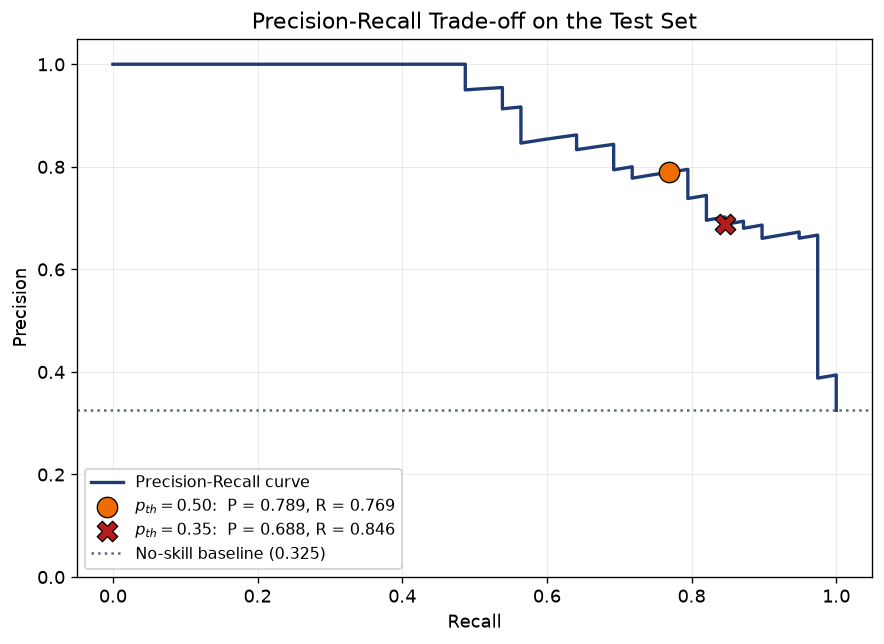

In [26]:
from sklearn.metrics import precision_recall_curve

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.plot(rec_curve, prec_curve, color='#1f3b73', linewidth=2,
        label='Precision-Recall curve')

# Mark the two operating points
for t, color, marker in ((0.50, '#ef6c00', 'o'), (0.35, '#b71c1c', 'X')):
    prec, rec, _, _ = metrics_at(t)
    ax.scatter(rec, prec, s=150, color=color, marker=marker, zorder=4,
               edgecolor='black', linewidth=0.8,
               label=rf'$p_{{th}} = {t:.2f}$:  P = {prec:.3f}, R = {rec:.3f}')

# A classifier with no skill sits at the positive-class rate
ax.axhline(y_test.mean(), color='#546e7a', linestyle=':', linewidth=1.5,
           label=f'No-skill baseline ({y_test.mean():.3f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Trade-off on the Test Set')
ax.set_ylim(0, 1.05)
ax.legend(framealpha=0.9, loc='lower left', fontsize=9.5)

plt.tight_layout()
save_fig('q2_5_precision_recall')
plt.show()

When the threshold is reduced from 0.50 to 0.35, the model becomes less strict about predicting the positive class. This means that more samples are classified as positive.

Because of this, the model can identify more of the actual positive samples, so recall increases. However, some of the additional positive predictions will be incorrect, which causes precision to decrease.

So there is a trade-off between precision and recall. In general, increasing recall means accepting more false positives, which can reduce precision.

A good example is medical screening, such as detecting cancer or another serious disease. In this situation, a false negative can be much more serious than a false positive. Missing a patient who actually has the disease could delay treatment, while a false positive can usually be handled with another test.

Therefore, in this type of application, it can be useful to lower the decision threshold. This increases recall and helps reduce the number of patients who are missed, even though it also produces more false alarms.


---
**Question 6**

A logistic regression model predicting whether a student passes with an $A^+$ ($y = 1$) yields:

$$\ln\left(\frac{p}{1-p}\right) = -7.2 + 0.08x_1 + 1.4x_2,$$

where $x_1$ denotes study hours, $x_2$ denotes GPA, and $p = P(y = 1 \mid x)$.

**(a) Direct Probability Computation:**

Derive the sigmoid expression $p = \frac{1}{1 + e^{-z}}$ from logit $z = \ln\left(\frac{p}{1-p}\right)$. Calculate the probability $p$ for a student with $x_1 = 45$ study hours and $x_2 = 3.4$ GPA.

**(b)** For a target probability $p = 0.70$ and GPA $x_2 = 3.4$, calculate the required study hours $x_1$.

---


Deriving the sigmoid function:

$$
\ln\left(\frac{p}{1-p}\right)=z
$$

Taking $e$ to both sides,

$$
\frac{p}{1-p}=e^z
$$

Multiplying both sides by $(1-p)$,

$$
p=e^z(1-p)
$$

Expanding,

$$
p=e^z-e^zp
$$

Moving the $p$ terms to the same side,

$$
p+e^zp=e^z
$$

Factoring out $p$,

$$
p(1+e^z)=e^z
$$

Therefore,

$$
p=\frac{e^z}{1+e^z}
$$

Dividing the numerator and denominator by $e^z$,

$$
p=\frac{1}{1+e^{-z}}
$$

In [27]:
# Numerical check of the hand calculations
b0, b1, b2 = -7.2, 0.08, 1.4

# (a) p at x1 = 45 study hours, x2 = 3.4 GPA
z = b0 + b1 * 45 + b2 * 3.4
p = 1 / (1 + np.exp(-z))
print(f"(a) z = {z:.4f},  p = {p:.4f}")

# (b) study hours needed for p = 0.70 at x2 = 3.4
z_target = np.log(0.70 / (1 - 0.70))          # logit of the target probability
x1 = (z_target - b0 - b2 * 3.4) / b1
print(f"(b) z = {z_target:.4f},  x1 = {x1:.4f} hours")

(a) z = 1.1600,  p = 0.7613
(b) z = 0.8473,  x1 = 41.0912 hours


(a) Probability for $x_1=45$ and $x_2=3.4$

The logistic model is

$$
z=-7.2+0.08x_1+1.4x_2.
$$

Substituting $x_1=45$ and $x_2=3.4$,

$$
z=-7.2+0.08(45)+1.4(3.4)
$$

$$
z=-7.2+3.6+4.76=1.16.
$$

The logistic function is

$$
p=\frac{1}{1+e^{-z}}.
$$

Therefore,

$$
p=\frac{1}{1+e^{-1.16}}
$$

$$
p\approx0.761.
$$

So, the predicted probability is approximately 0.76, or 76%.

(b) Finding $x_1$ when $p=0.70$

The relationship between the probability and the linear score is

$$
z=\ln\left(\frac{p}{1-p}\right).
$$

For $p=0.70$,

$$
z=\ln\left(\frac{0.70}{0.30}\right)
$$

$$
z\approx0.847.
$$

Using the model,

$$
0.847=-7.2+0.08x_1+1.4(3.4).
$$

Since

$$
1.4(3.4)=4.76,
$$

we get

$$
0.847=-7.2+0.08x_1+4.76.
$$

Rearranging,

$$
0.08x_1=0.847+7.2-4.76
$$

$$
0.08x_1=3.287.
$$

Therefore,

$$
x_1=\frac{3.287}{0.08}\approx41.1.
$$

So, the student would need approximately 41.1 study hours for the model to predict a probability of 70%.
